# 04 – Supervised Learning: Prediktion av Depression

Mål: träna och jämföra **fyra klassificeringsmodeller** som förutsäger `Depression` från
livsstils- och studievariablerna. Bygger på `student_depression_clean.csv` från
`01_Dataforberedelse.ipynb`.

**Arbetsordningen är vald för att skydda testsetet:**

1. **Sektion 1** - features definieras, datan delas, testsetet låses in.
2. **Sektion 2** - modellerna tävlar med cross-validation på *enbart träningsdatan*.
3. **Sektion 3** - champion-modellen väljs, baserat på CV-resultat + praktiska avvägningar.
4. **Sektion 4** - först nu rörs testsetet: slututvärdering av samtliga modeller.
5. **Sektion 5** - slutsatser.

Poängen med ordningen: väljer man modell *efter* att ha sett testresultaten har testsetet
i smyg blivit en del av träningen, och siffrorna är inte längre en ärlig skattning av
prestanda på ny data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
)

from tensorflow import keras

# Reproducerbarhet: sätter python-, numpy- och tensorflow-frön i ett svep.
# OBS: neurala nät är trots detta inte perfekt reproducerbara (parallellism i
# träningen kan ge små skillnader mellan körningar) - men resultaten ska ligga
# mycket nära dem som redovisas här.
keras.utils.set_random_seed(42)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Visuell stil

Samma palett och stil som i `02_EDA.ipynb` och `03_Unsupervised.ipynb`, plus fyra fasta
modellfärger (samma kategoriska ordning som klusterfärgerna i 03 - blå, orange, turkos, gul).

In [2]:
# Fast, återanvändbar färgpalett - ett blå/röd-par som är valt för att gå att skilja
# på även för färgblinda.
PALETTE = {
    "blue": "#2a78d6",     # serie 1 / ena polen i diverging-skalor
    "red": "#e34948",      # serie 2 / andra polen i diverging-skalor
    "orange": "#eb6834",   # serie 3
    "neutral": "#f0efec",  # mittpunkt i diverging-skalor
    "grid": "#e1e0d9",     # hårfina gridlines
    "ink": "#0b0b0b",      # primär textfärg
    "muted": "#898781",    # sekundär text
    "surface": "#fcfcfb",  # bakgrund
}

# Sätts EN gång, gäller sedan automatiskt för alla diagram nedan.
plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": PALETTE["ink"],
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],
    "ytick.color": PALETTE["ink"],
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlelocation": "left",
    "figure.dpi": 200,
    "savefig.dpi": 200,
})

sns.set_palette([PALETTE["blue"], PALETTE["red"], PALETTE["orange"]])

# En fast färg per modell - används i ROC-/PR-kurvorna så att samma modell alltid
# har samma färg genom hela notebooken.
MODEL_COLORS = {
    "Logistisk regression": PALETTE["blue"],
    "Random Forest": PALETTE["orange"],
    "Gradient boosting": "#1baf7a",
    "Neuralt nätverk (MLP)": "#eda100",
}

## Sektion 1 – Förberedelse

**Features.** Alla variabler utom tre:

- **`Depression`** - målvariabeln.
- **`Have you ever had suicidal thoughts ?`** - exkluderas som metodbeslut från EDA:n.
  Suicidtankar är ett *symptom* på depression enligt diagnoskriterierna (DSM-5), inte en
  oberoende riskfaktor. Att ha med den hade mest mätt hur väl ett symptom förutsäger sin
  egen diagnos - en form av målläckage som ger imponerande men meningslösa siffror.
- **`City`** - droppas. Skillnaderna mellan städer är små (svagare samband med Depression
  än t.o.m. Sleep Duration), och variabeln tillför i praktiken ingen information utöver de
  övriga - men hade kostat 30 extra kolumner vid one-hot-kodning.

`Age` inkluderas - EDA:n visade en stark, monotont fallande trend (71% depression bland
18-21-åringar ned till 41% bland 31-35).

**Split och skalning.** Stratifierad 80/20-split (bevarar 58.6/41.4-balansen i båda
delarna - målvariabeln är jämn nog att ingen balanseringsteknik som SMOTE behövs).
`StandardScaler` fitas **enbart på träningsdatan** och appliceras sedan på båda delarna -
fitas den på allt läcker testsetets medelvärden in i träningen.

**Härifrån är testsetet låst.** Det rörs inte förrän i Sektion 4, efter att modellvalet
redan är fattat.

In [3]:
df = pd.read_csv("student_depression_clean.csv")

feature_cols = [
    "Gender", "Age", "Academic Pressure", "CGPA", "Study Satisfaction",
    "Sleep Duration", "Dietary Habits", "Work/Study Hours", "Financial Stress",
    "Family History of Mental Illness",
]
X = df[feature_cols]
y = df["Depression"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Skalning för det neurala nätet: fit ENDAST på train, transformera båda.
# (De klassiska modellerna får sin skalning via Pipeline i Sektion 2 istället -
# då görs den dessutom om inuti varje CV-fold, vilket är ännu striktare.)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rader | Test: {X_test.shape[0]} rader | {X.shape[1]} features")
print(f"Depression-andel train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Train: 22273 rader | Test: 5569 rader | 10 features
Depression-andel train: 0.586 | test: 0.586


## Sektion 2 – Modelltävling med cross-validation (endast träningsdata)

Tre klassiska modeller jämförs med **5-fold stratified cross-validation** på träningsdatan,
med **AUC-ROC** som mått. Varje modell ligger i en `Pipeline` med sin egen `StandardScaler` -
då görs skalningen om inuti varje fold, så att inte ens valideringsfoldens medelvärden
läcker in i träningen. (Trädmodellerna behöver strikt taget ingen skalning, men den är
ofarlig och håller uppställningen enhetlig.)

Modellerna är valda för att de gör **olika antaganden om datan**:

- **Logistisk regression** - sambanden är linjära och additiva. Baslinje, mest tolkningsbar.
- **Random Forest** (200 träd) - det finns trösklar och samspel mellan variabler.
- **Gradient boosting** (`HistGradientBoostingClassifier`) - samma antagande som Random
  Forest men sekventiellt byggd; brukar vara starkast på tabelldata.

In [4]:
models = {
    "Logistisk regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient boosting": HistGradientBoostingClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s} CV AUC-ROC: {scores.mean():.4f} ± {scores.std():.4f}")

Logistisk regression   CV AUC-ROC: 0.8709 ± 0.0070


Random Forest          CV AUC-ROC: 0.8590 ± 0.0075


Gradient boosting      CV AUC-ROC: 0.8694 ± 0.0078


### Neuralt nätverk (Keras-MLP)

Arkitektur: **64 → 32 → 1** (ReLU i de dolda lagren, sigmoid ut), binary crossentropy,
Adam. **Early stopping** övervakar valideringsförlusten och återställer de bästa vikterna -
valideringsdatan är de sista 15% av *träningsdatan* (`validation_split=0.15`), testsetet
är fortfarande orört.

Nätet får **ingen 5-fold CV** som de klassiska modellerna - att träna om det fem gånger
kostar mer än det ger här. Dess valideringssiffra nedan är alltså inte exakt jämförbar
med CV-siffrorna (en split istället för fem), vilket vi tar med oss i tolkningen.

In [5]:
mlp = keras.Sequential([
    keras.layers.Input(shape=(len(feature_cols),)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])
mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), "accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = mlp.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=100, batch_size=256,
    callbacks=[early_stop],
    verbose=0,
)

n_epochs = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
mlp_val_auc = max(history.history["val_auc"])
print(f"Tränade {n_epochs} epoker (early stopping) - bästa vikter från epok {best_epoch}")
print(f"Bästa validerings-AUC: {mlp_val_auc:.4f}")

Tränade 23 epoker (early stopping) - bästa vikter från epok 13
Bästa validerings-AUC: 0.8756


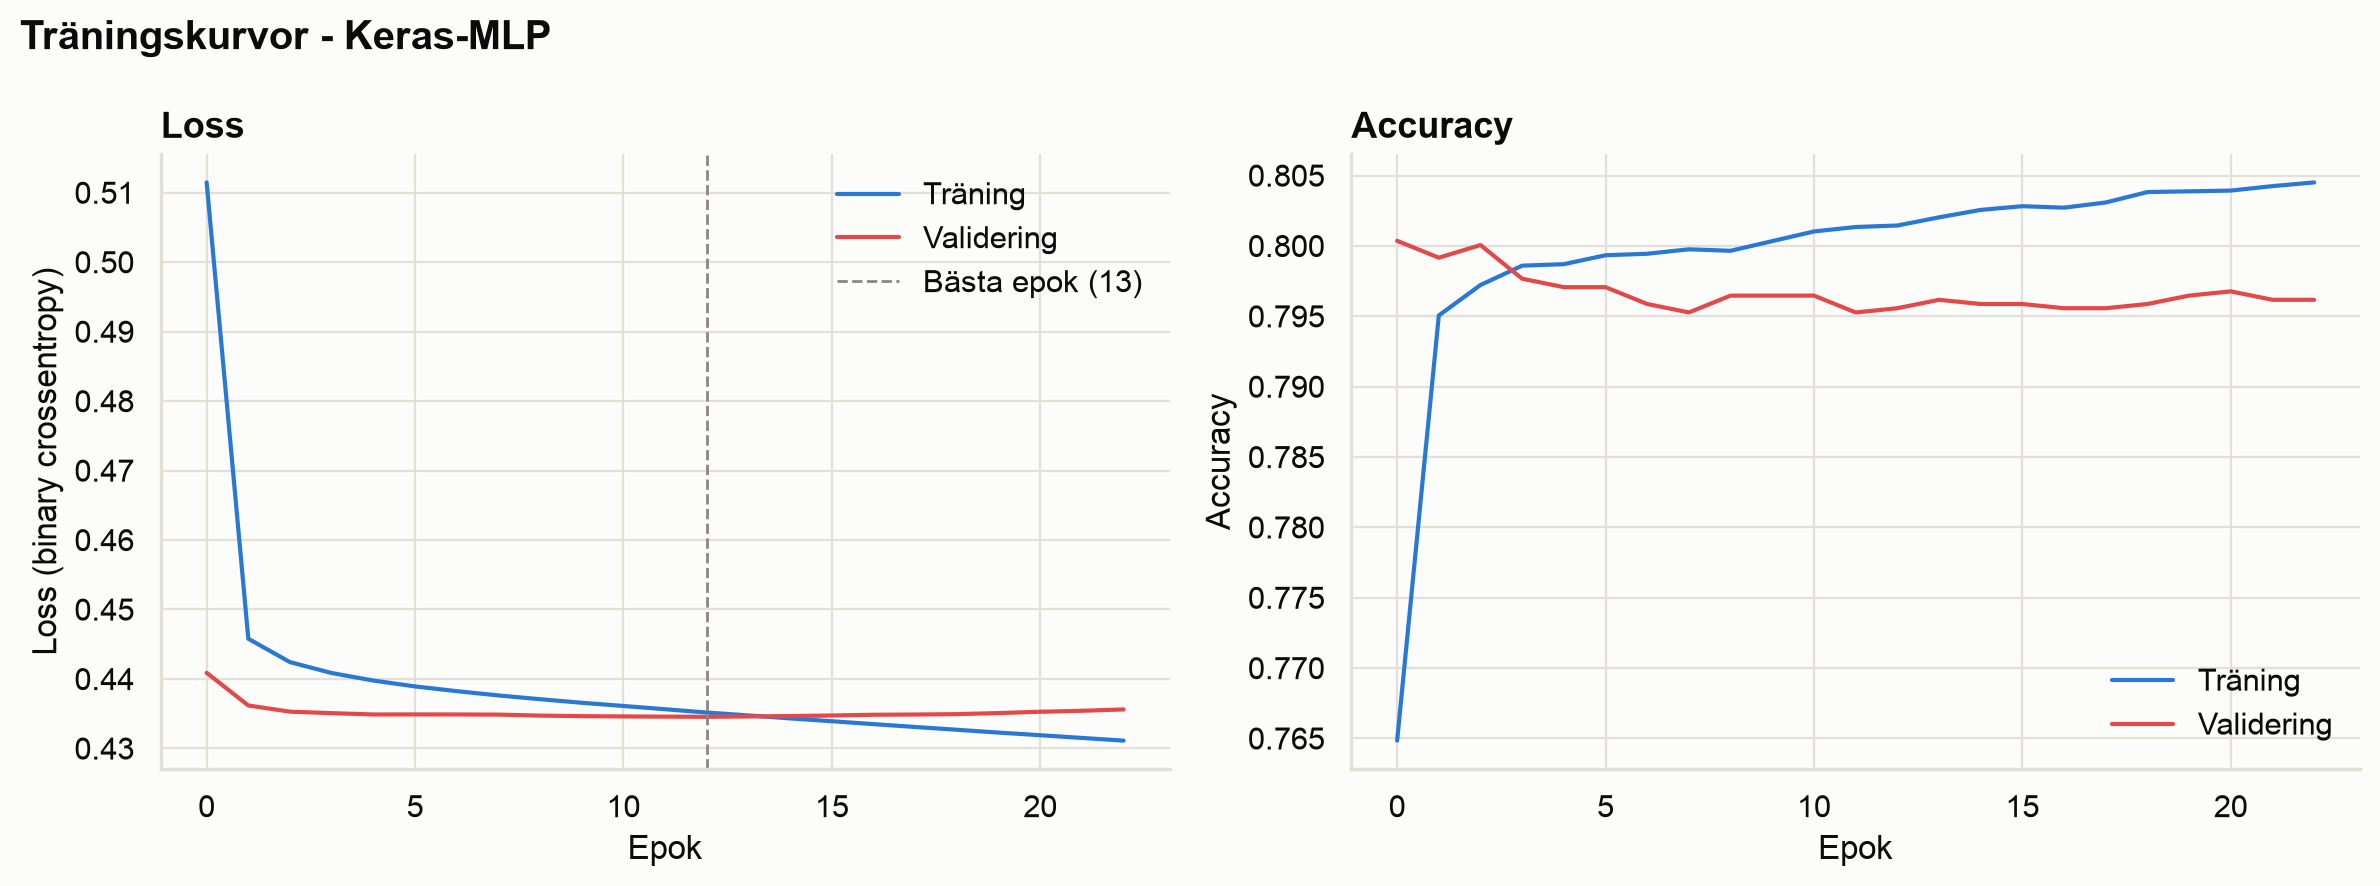

In [6]:
# Träningskurvor: loss och accuracy, träning vs validering. Om kurvorna glider isär
# (val-loss stiger medan train-loss sjunker) övertränar nätet - early stopping ska
# fånga det innan det går för långt.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["loss"], color=PALETTE["blue"], label="Träning")
axes[0].plot(history.history["val_loss"], color=PALETTE["red"], label="Validering")
axes[0].axvline(best_epoch - 1, color=PALETTE["muted"], linestyle="--", linewidth=1,
                label=f"Bästa epok ({best_epoch})")
axes[0].set_xlabel("Epok")
axes[0].set_ylabel("Loss (binary crossentropy)")
axes[0].set_title("Loss")
axes[0].legend(frameon=False)

axes[1].plot(history.history["accuracy"], color=PALETTE["blue"], label="Träning")
axes[1].plot(history.history["val_accuracy"], color=PALETTE["red"], label="Validering")
axes[1].set_xlabel("Epok")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend(frameon=False)

fig.suptitle("Träningskurvor - Keras-MLP", fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
plt.show()

In [7]:
# Sammanställning av modelltävlingen. MLP:ns siffra kommer från EN valideringssplit
# (inte 5-fold CV) och är märkt därefter.
cv_table = pd.DataFrame([
    {"Modell": name, "AUC-ROC (träningsdata)": f"{s.mean():.4f} ± {s.std():.4f}", "Metod": "5-fold CV"}
    for name, s in cv_results.items()
] + [
    {"Modell": "Neuralt nätverk (MLP)", "AUC-ROC (träningsdata)": f"{mlp_val_auc:.4f}",
     "Metod": "valideringssplit (15%)"}
])
cv_table

,Modell,AUC-ROC (träningsdata),Metod
0,Logistisk regression,0.8709 ± 0.0070,5-fold CV
1,Random Forest,0.8590 ± 0.0075,5-fold CV
2,Gradient boosting,0.8694 ± 0.0078,5-fold CV
3,Neuralt nätverk (MLP),0.8756,valideringssplit (15%)


## Sektion 3 – Välj champion-modell

**Beslutet fattas här - innan testsetet rörs.** Underlaget är CV-tabellen ovan plus
praktiska avvägningar.

**Vad CV-resultaten säger.** Fältet är tätt: logistisk regression 0.8709, gradient
boosting 0.8694, Random Forest 0.8590 - och skillnaden mellan de två bästa (0.0015) är
långt inne i bruset (varje modells std över foldarna är ±0.007). MLP:ns 0.8756 ser högst
ut men kommer från en enda valideringssplit och är inte direkt jämförbar med CV-siffrorna.
Rent numeriskt går det alltså inte att skilja logistisk regression, gradient boosting och
MLP åt - det enda säkra är att Random Forest ligger något efter.

Att den *enklaste* modellen håller jämna steg med de flexibla är i sig ett fynd: sambanden
i datat verkar vara i huvudsak **linjära och additiva**. Det rimmar med klustringen i
`03_Unsupervised.ipynb`, som inte heller hittade några skarpa grupper eller samspel -
bara ett kontinuum där stressnivån dominerar.

**Praktiska avvägningar.** När prestandan inte skiljer avgör andra egenskaper:

- **Tolkningsbarhet.** Logistisk regression kan förklaras koefficient för koefficient
  ("en nivå högre Academic Pressure ökar oddsen för depression med X%"). I en kontext som
  handlar om studenters psykiska hälsa är det ett tungt argument - en modell vars beslut
  går att granska och förklara är värd mer än en marginellt vassare svart låda.
- **Enkelhet och robusthet.** Inga hyperparametrar att underhålla, snabb att träna om,
  deterministisk.

**Recall väger extra tungt.** I en depression-screening är de två felen inte likvärdiga:
ett **falskt negativ** (en deprimerad student som modellen missar) betyder att någon som
behöver stöd inte fångas upp, medan ett **falskt positivt** kostar ett uppföljningssamtal
i onödan. Vi vill därför ha hög recall för Depression-klassen, och en modell med
välkalibrerade sannolikheter (som logistisk regression) gör det dessutom enkelt att sänka
beslutströskeln under 0.5 om screening-kontexten kräver ännu högre recall.

**Champion: logistisk regression.** Bäst CV-AUC bland de jämförbara modellerna, i praktiken
likvärdig med de flexibla alternativen i prestanda - och överlägsen i tolkningsbarhet.

## Sektion 4 – Slututvärdering på testsetet

**Viktigt:** modellvalet i Sektion 3 fattades på CV-resultaten, **innan** testresultaten
nedan var kända. Testsiffrorna redovisas för samtliga fyra modeller för transparensens
skull - de används inte för att välja modell i efterhand. Det är skillnaden mellan en
ärlig skattning av prestanda på ny data och en siffra som i smyg är anpassad efter testsetet.

Nu fittas varje klassisk modell (pipeline med skalning) på hela träningsdatan och
utvärderas på testsetet. Det neurala nätet är redan tränat.

In [8]:
# Fitta de tre klassiska pipelinesarna på hela träningsdatan.
fitted = {}
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    fitted[name] = pipe.fit(X_train, y_train)

# Sannolikheter och klassprediktioner (tröskel 0.5) på testsetet för alla fyra.
test_proba = {name: pipe.predict_proba(X_test)[:, 1] for name, pipe in fitted.items()}
test_proba["Neuralt nätverk (MLP)"] = mlp.predict(X_test_scaled, verbose=0).ravel()

test_pred = {name: (p >= 0.5).astype(int) for name, p in test_proba.items()}
print("Prediktioner klara för:", ", ".join(test_pred))

Prediktioner klara för: Logistisk regression, Random Forest, Gradient boosting, Neuralt nätverk (MLP)


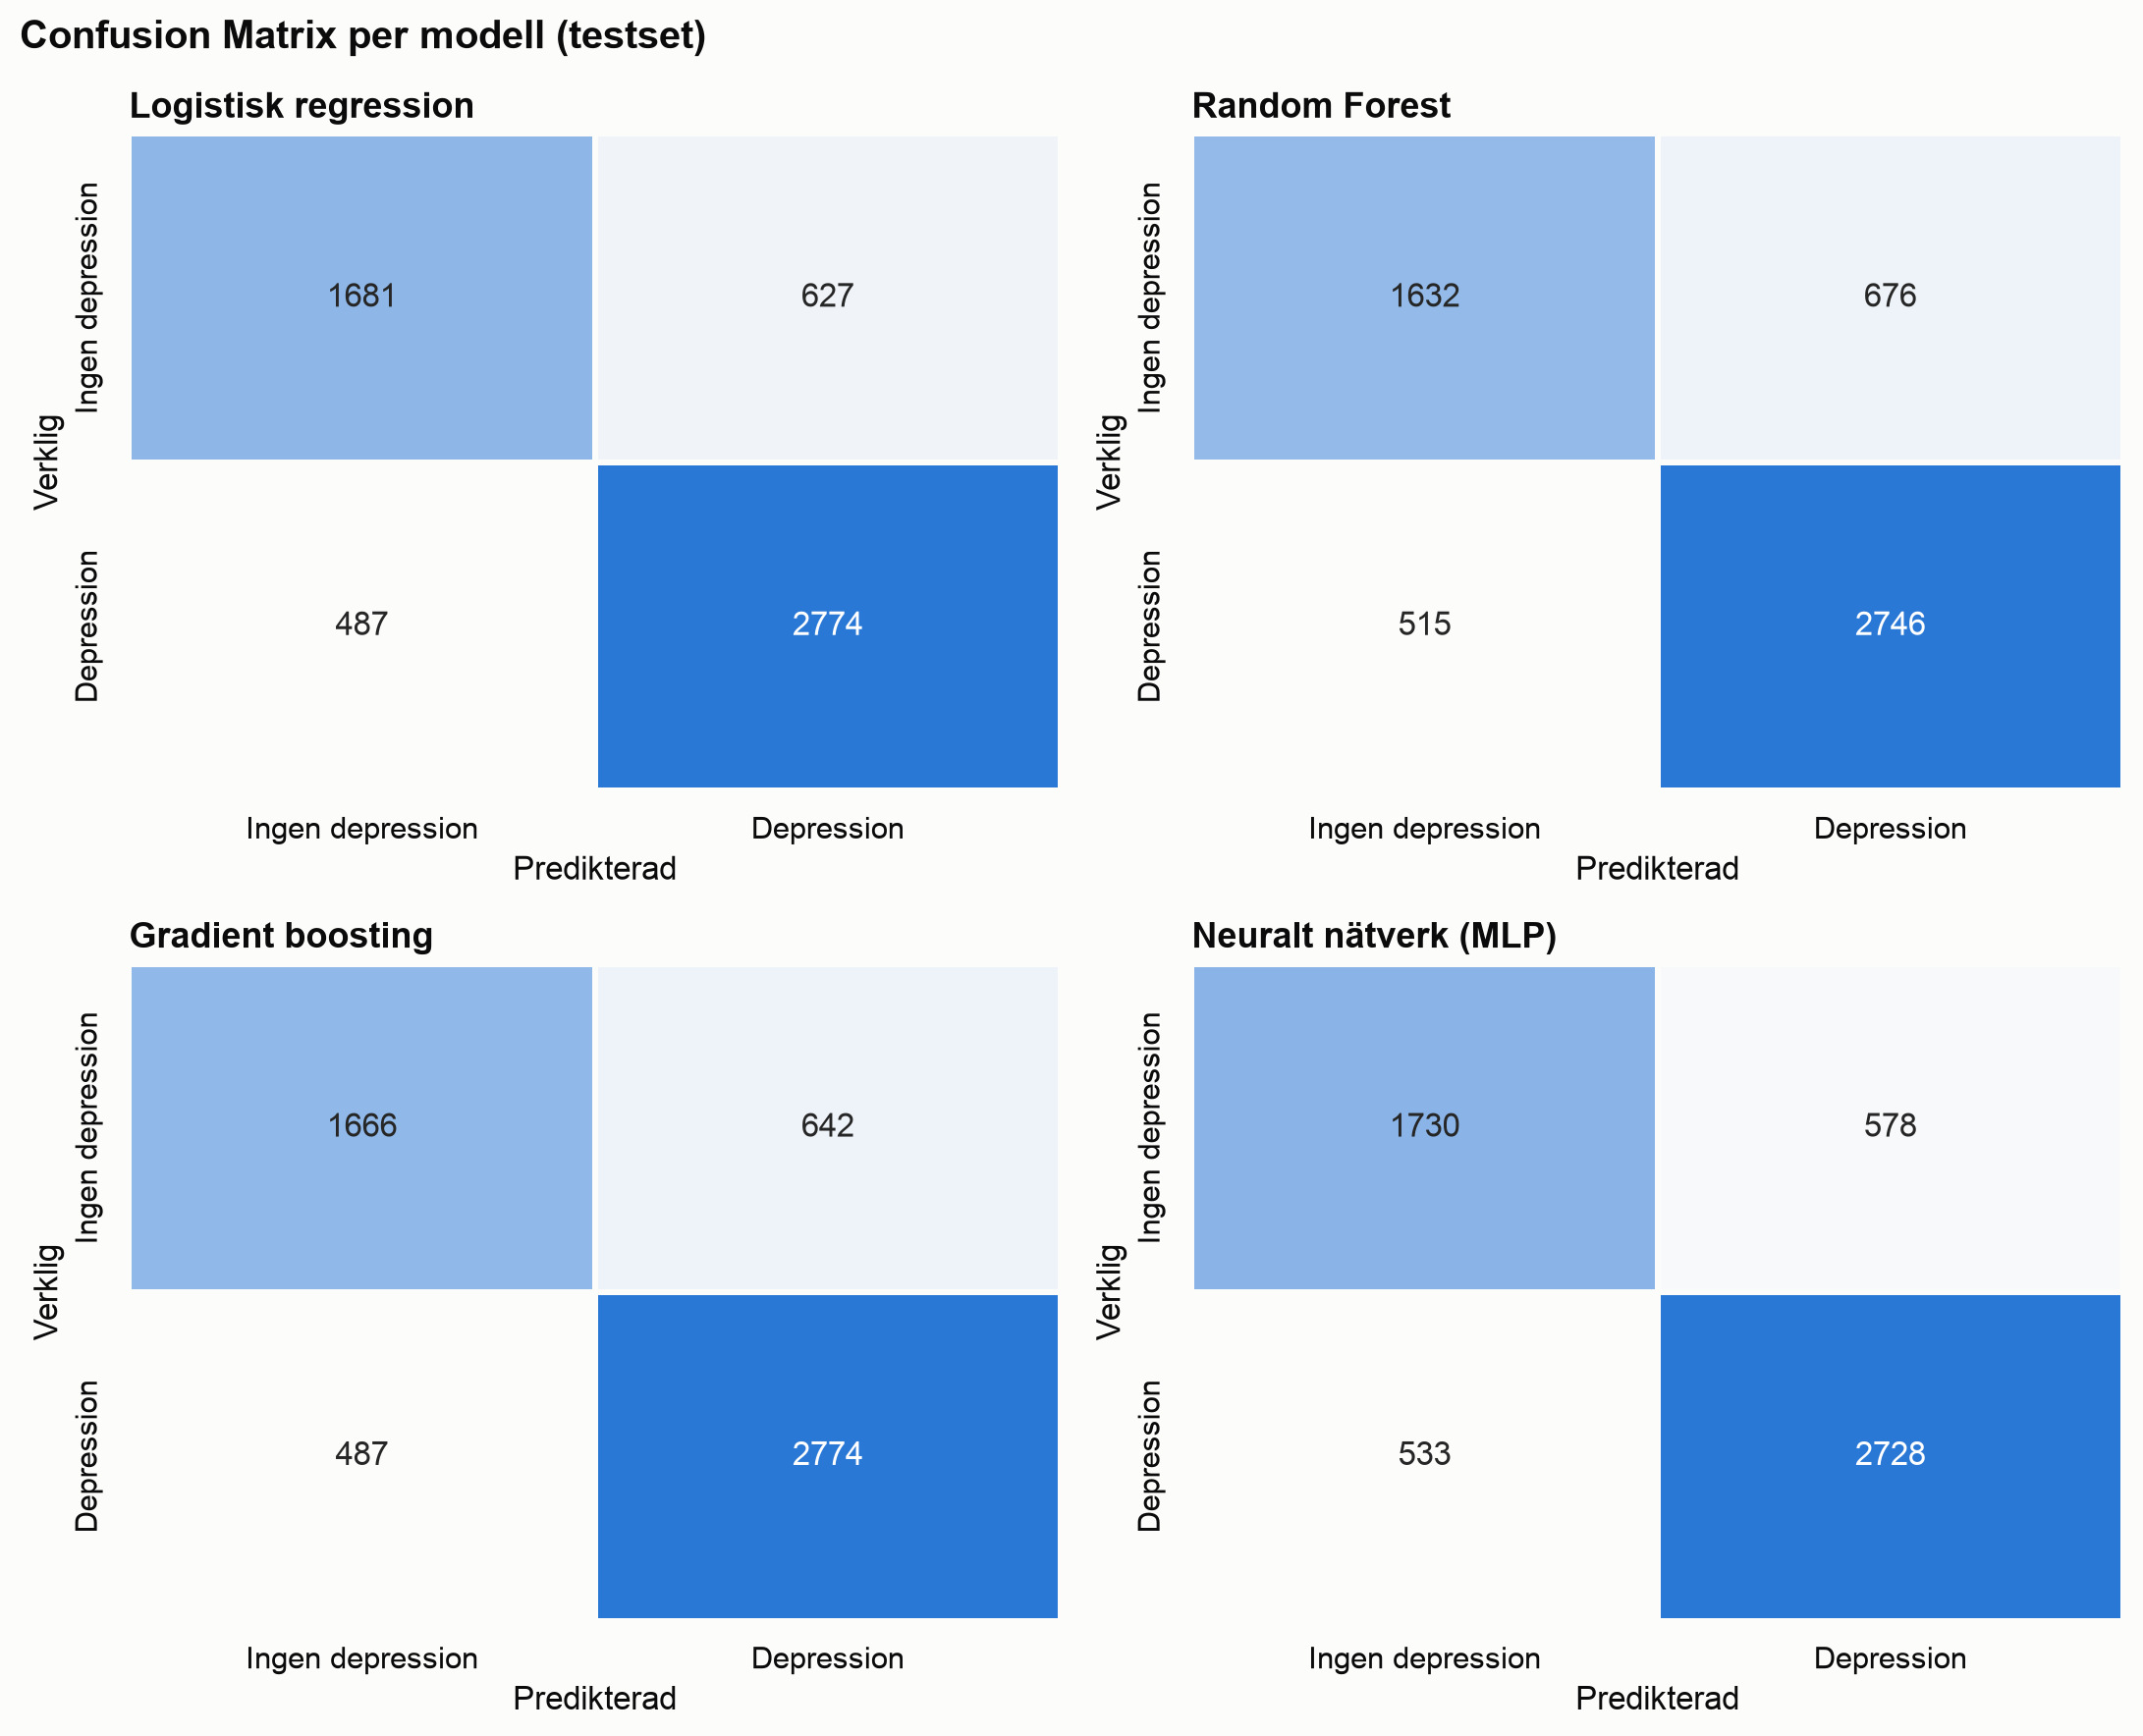

In [9]:
# Confusion matrix för samtliga fyra modeller i en 2x2-grid.
# Rader = verklighet, kolumner = prediktion.
from matplotlib.colors import LinearSegmentedColormap

cm_cmap = LinearSegmentedColormap.from_list("cm_blue", [PALETTE["surface"], PALETTE["blue"]])
labels = ["Ingen depression", "Depression"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, pred) in zip(axes.ravel(), test_pred.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cm_cmap, cbar=False,
        xticklabels=labels, yticklabels=labels,
        linewidths=2, linecolor=PALETTE["surface"], ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predikterad")
    ax.set_ylabel("Verklig")

fig.suptitle("Confusion Matrix per modell (testset)", fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
plt.show()

In [10]:
# Classification report per modell: precision, recall och F1 per klass.
for name, pred in test_pred.items():
    print("=" * 58)
    print(name)
    print("=" * 58)
    print(classification_report(y_test, pred, target_names=labels))

Logistisk regression
                  precision    recall  f1-score   support

Ingen depression       0.78      0.73      0.75      2308
      Depression       0.82      0.85      0.83      3261

        accuracy                           0.80      5569
       macro avg       0.80      0.79      0.79      5569
    weighted avg       0.80      0.80      0.80      5569

Random Forest
                  precision    recall  f1-score   support

Ingen depression       0.76      0.71      0.73      2308
      Depression       0.80      0.84      0.82      3261

        accuracy                           0.79      5569
       macro avg       0.78      0.77      0.78      5569
    weighted avg       0.78      0.79      0.78      5569

Gradient boosting
                  precision    recall  f1-score   support

Ingen depression       0.77      0.72      0.75      2308
      Depression       0.81      0.85      0.83      3261

        accuracy                           0.80      5569
       macr

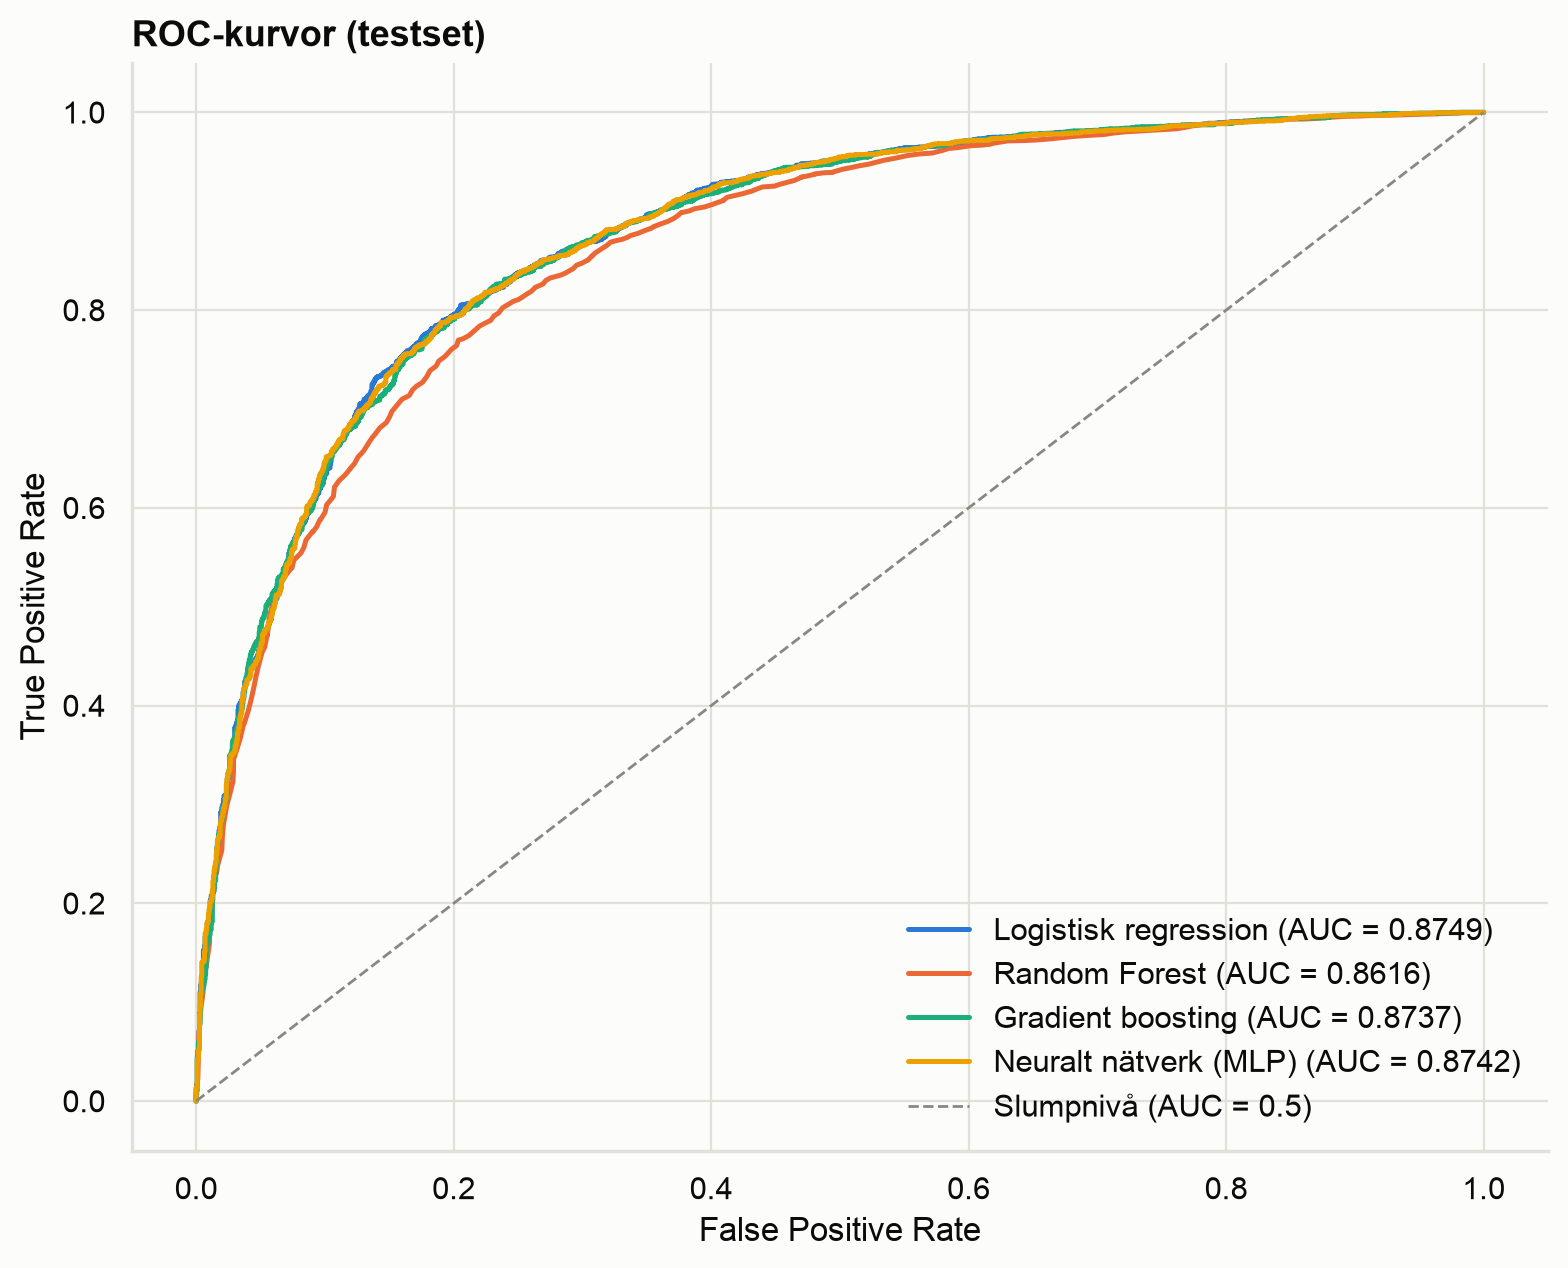

In [11]:
# ROC-kurvor för alla fyra modeller i EN figur - direkt jämförbara.
fig, ax = plt.subplots(figsize=(8, 6.5))
for name, proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=1.8,
            label=f"{name} (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], color=PALETTE["muted"], linestyle="--", linewidth=1,
        label="Slumpnivå (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-kurvor (testset)")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

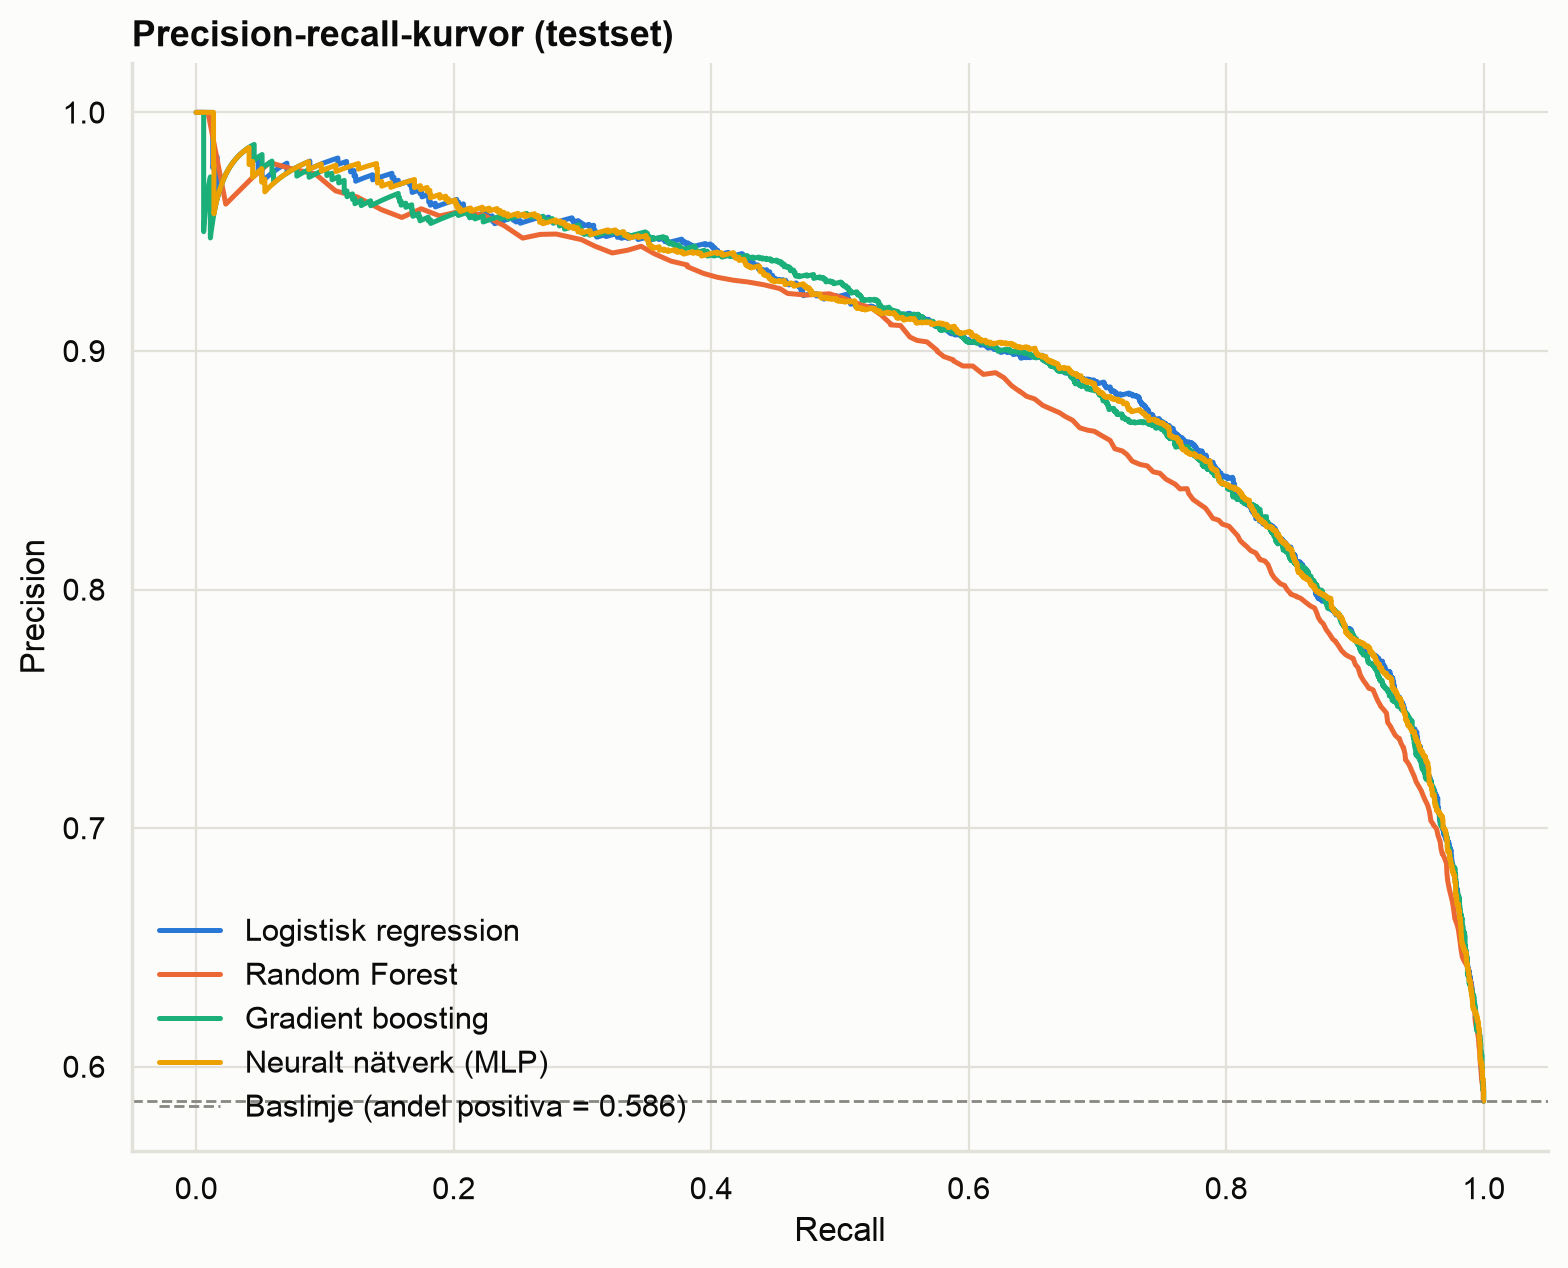

In [12]:
# Precision-recall-kurvor i EN figur. Baslinjen är andelen positiva i testsetet -
# en modell utan information hamnar där.
fig, ax = plt.subplots(figsize=(8, 6.5))
for name, proba in test_proba.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, color=MODEL_COLORS[name], linewidth=1.8, label=name)
ax.axhline(y_test.mean(), color=PALETTE["muted"], linestyle="--", linewidth=1,
           label=f"Baslinje (andel positiva = {y_test.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall-kurvor (testset)")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

In [13]:
# Sammanfattande jämförelsetabell. CV-kolumnen är från Sektion 2 (träningsdata) -
# ligger test-AUC nära CV-AUC har modellen inte överanpassats.
rows = []
for name in test_proba:
    pred, proba = test_pred[name], test_proba[name]
    if name in cv_results:
        cv_str = f"{cv_results[name].mean():.4f} ± {cv_results[name].std():.4f}"
    else:
        cv_str = f"{mlp_val_auc:.4f} (val-split)"
    rows.append({
        "Modell": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC-ROC (test)": roc_auc_score(y_test, proba),
        "AUC-ROC (träning, CV)": cv_str,
    })

results = pd.DataFrame(rows).set_index("Modell").round(4)
results

,Accuracy,Precision,Recall,F1,AUC-ROC (test),"AUC-ROC (träning, CV)"
Modell,,,,,,
Logistisk regression,0.8000,0.8156,0.8507,0.8328,0.8749,0.8709 ± 0.0070
Random Forest,0.7861,0.8025,0.8421,0.8218,0.8616,0.8590 ± 0.0075
Gradient boosting,0.7973,0.8121,0.8507,0.8309,0.8737,0.8694 ± 0.0078
Neuralt nätverk (MLP),0.8005,0.8252,0.8366,0.8308,0.8742,0.8756 (val-split)


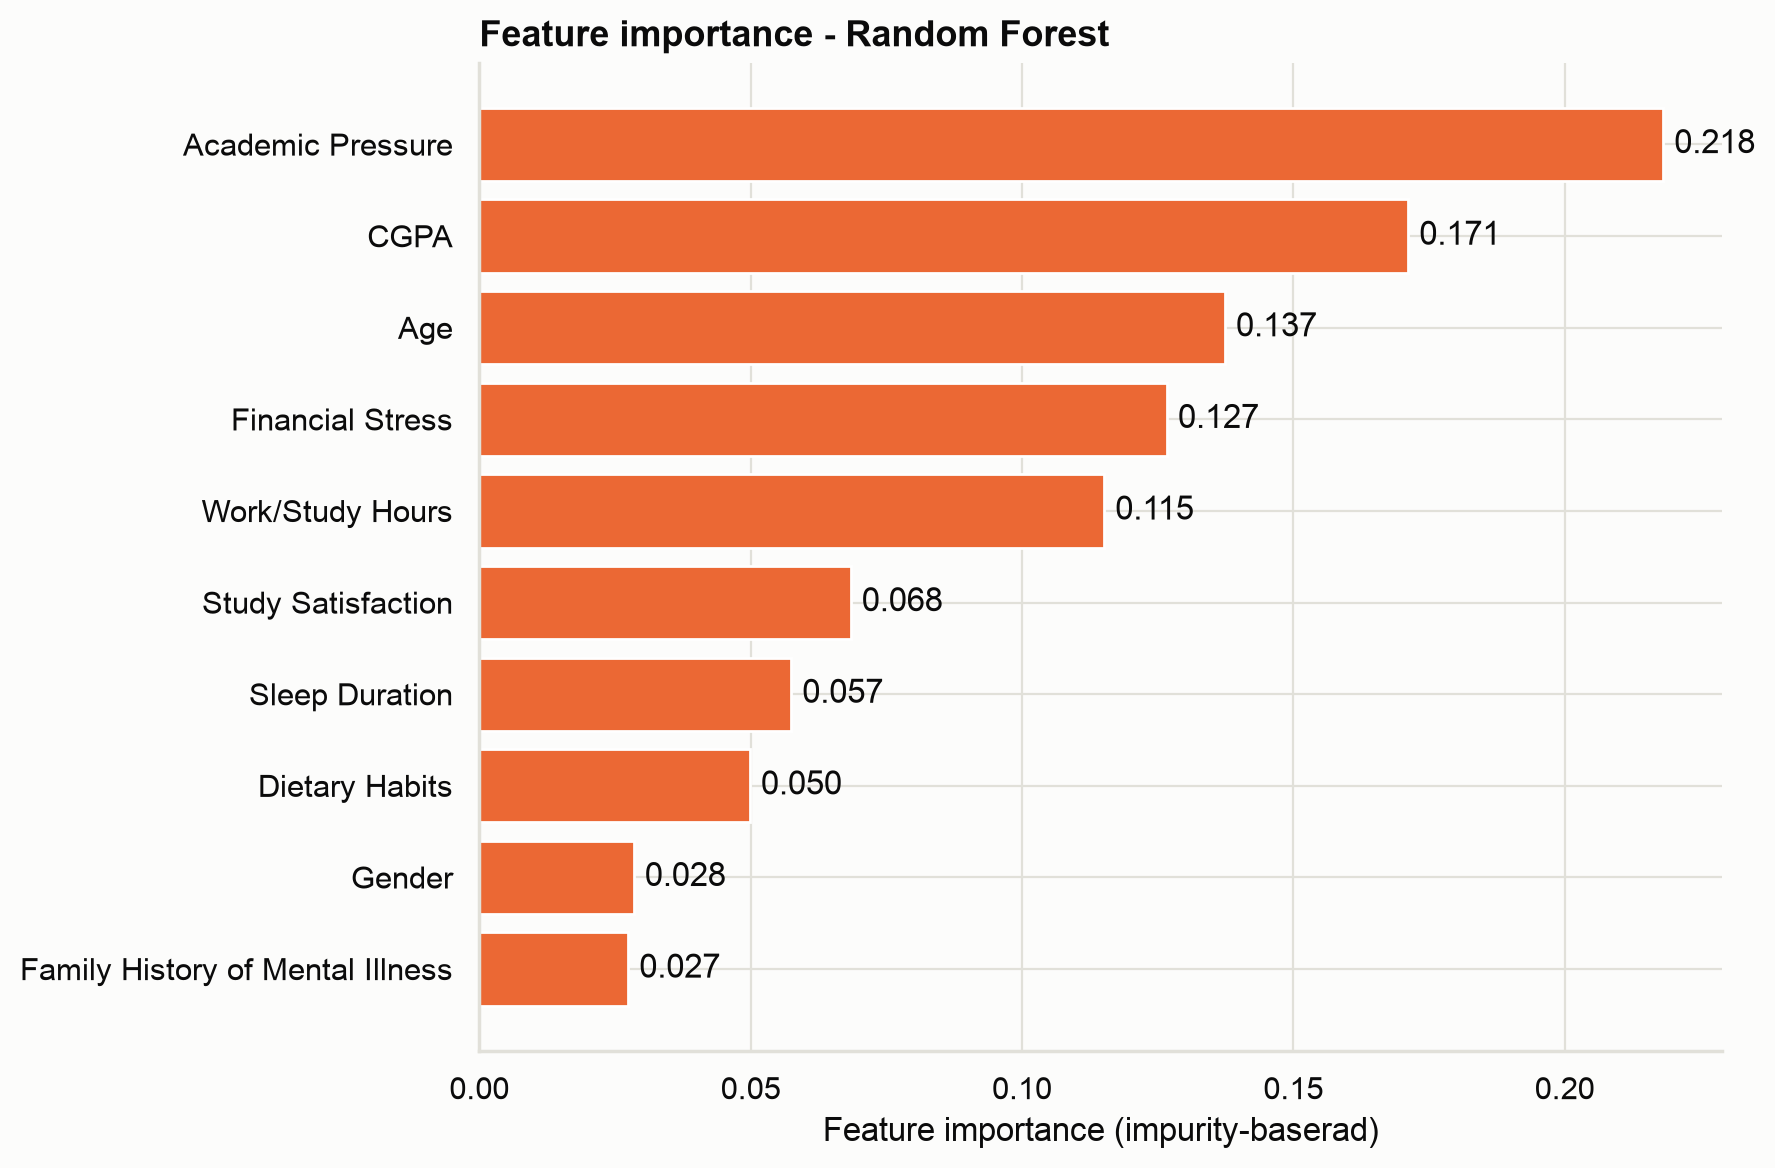

In [14]:
# Feature importance från Random Forest - vilka variabler lutar sig modellen mot?
rf_model = fitted["Random Forest"].named_steps["model"]
importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance.index, importance.values, color=PALETTE["orange"])
ax.bar_label(bars, fmt="%.3f", padding=4, color=PALETTE["ink"])
ax.set_xlabel("Feature importance (impurity-baserad)")
ax.set_title("Feature importance - Random Forest")
plt.tight_layout()
plt.show()

## Sektion 5 – Slutsatser

**Stämde CV-valet med testresultaten? Ja.** Logistisk regression fick högst test-AUC
(0.8749), tätt följd av MLP (0.8742) och gradient boosting (0.8737), med Random Forest
sist (0.8616) - exakt samma inbördes ordning som cross-validationen förutsade bland de
jämförbara modellerna. Test-AUC ligger dessutom aningen *över* CV-AUC för alla (t.ex.
0.8749 mot 0.8709 för champion) och väl inom foldarnas spridning - ingen modell har
överanpassats. Champion-modellen når **accuracy 80.0%** och **recall 85.1%** för
Depression-klassen vid tröskel 0.5.

**Fyra modeller, ett samstämmigt svar.** Hela fältet ryms inom 0.86-0.87 i AUC, och det
neurala nätet slog inte de klassiska modellerna. Det är det förväntade utfallet på
strukturerad tabelldata av den här storleken - djupinlärningens styrkor ligger i
ostrukturerad data (bild, text, ljud) - och det bekräftar bilden från Sektion 3: sambanden
är i huvudsak linjära och additiva, och taket kring AUC 0.87 sätts av informationen i
datat, inte av modellvalet.

**Feature importance stämmer i stort med EDA:n - med en lärorik avvikelse.** Random
Forest lutar sig mest mot Academic Pressure (0.218), med Age, Financial Stress och
Work/Study Hours strax bakom - samma variabler som toppade korrelationsanalysen i
`02_EDA.ipynb`. Avvikaren är **CGPA på andra plats (0.171) trots korrelation ~0.02 i
EDA:n**. Det ska inte läsas som att betyg plötsligt blivit viktigt: impurity-baserad
feature importance överskattar systematiskt kontinuerliga variabler med många unika
värden (CGPA har hundratals, skalvariablerna bara 3-5), eftersom de erbjuder fler
möjliga splitpunkter. En påminnelse om att läsa importance-mått kritiskt.

**Jämförelse med förväntan.** Som riktmärke brukar ~80-85% accuracy anses bra för
depression-prediktion från livsstils-/studievariabler *utan* symptomvariabler - vi landar
på 80%. Kaggle-notebooks på samma dataset når ofta 90%+, men gör det med
`Have you ever had suicidal thoughts ?` som feature. Vår lägre siffra är ett **medvetet
metodval, inte en svaghet**: suicidtankar är ett symptom på depression enligt DSM-5, och
en modell som "förutsäger" en diagnos från dess eget symptom mäter mest sin egen läcka.
Våra 80% beskriver vad som faktiskt går att säga om depression *innan* symptomen tillfrågas -
vilket också är den enda siffran som är meningsfull för screening.

**Vad tar vi med oss?**

- **Logistisk regression räcker** - och är att föredra: likvärdig prestanda, full
  tolkningsbarhet, enkel att underhålla. Komplexitet ska motiveras av prestandavinst,
  och någon sådan fanns inte här.
- **Stress dominerar.** Academic Pressure och Financial Stress bär modellerna, precis som
  de bar klustringen i 03. Age är den starkaste icke-stress-variabeln.
- **I en screening-tillämpning** bör beslutströskeln sättas under 0.5 för att pressa
  recall ytterligare - kostnaden för ett missat fall är högre än för ett falskt larm, och
  PR-kurvan visar att det finns utrymme att byta precision mot recall.
- **Hela ML-processen hänger ihop:** EDA:ns korrelationer, klustringens kontinuum-fynd och
  modelljämförelsens platta fält pekar alla på samma slutsats om datat - få starka, mest
  additiva samband med stress i centrum. Att tre oberoende metoder ger samma bild är det
  starkaste beviset på att den stämmer.